

# Project Data Science
***Auteurs : DIALLO Bintou, RIPOLL Thomas***

***Thématique Business:***

Fidélisation et anticipation de la perte de clientèle dans les télécoms

***Contexte métier:***

Telco est une entreprise de télécommunications qui fournit des services essentiels de téléphonie et d'accès à internet. Son rôle principal est d'assurer une connectivité fiable tout en accompagnant ses abonnés au quotidien. À travers son service client, elle se charge de résoudre d'éventuelles pannes techniques et de gérer toutes les demandes liées aux abonnements, aux équipements ou à la facturation.

***Jeu de données:***

* **Source de données :** [Kaggle.com](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
* **Nom du dataset :** `WA_Fn-UseC_-Telco-Customer-Churn`
* **Volume :** 977,5 Ko, 7 043 lignes
* **Variables :** 23 variables au total (String : 12, Boolean : 5, Integer : 2, Other : 2). Ces variables se divisent en trois grandes catégories :
    * **Données démographiques :** Sexe, âge, situation familiale.
    * **Services souscrits :** Téléphone, lignes multiples, internet, sécurité en ligne, support technique, streaming, etc.
    * **Informations de compte :** Ancienneté du client, type de contrat, méthode de paiement, facturation mensuelle et totale.

***Problématique business:***

Nous sommes Data Scientist au sein d’une entreprise de télécommunication Telco. Notre entreprise souhaiterais prévoir les moments où les clients seraient les plus à même de résilier leurs abonnements et services souscrits au sein de notre entreprise, afin de savoir quand leur proposer des offres, ou mettre en place différentes techniques marketing pour de les fidéliser de nouveau, et éviter qu’ils ne se désabonnent. Parvenir à prédire ceci permettrait à l’entreprise d’éviter une perte de clients et donc une potentielle baisse de leur chiffre d’affaire.


***Objectif Data Science:***

1. Réaliser une analyse exploratoire (EDA) pour identifier les facteurs qui influencent le plus le départ d'un client (ex: type de contrat, absence de support technique, facturation élevée).

2. Développer un modèle de classification binaire (Supervised Learning) capable de prédire avec précision la probabilité de désabonnement d'un client (Churn = Oui ou Non) à partir de ses caractéristiques et de son historique.

##  Analyse exploratoire des données (EDA)
À réaliser dans un notebook Jupyter (.ipynb) avec analyse de la structure, statistiques
descriptives, valeurs manquantes, visualisations, corrélations, outliers et hypothèses.

### EDA-1 : Analyse de la structure du dataset
Vérification de la taille des données, du nom des colonnes et du type de variables:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

# 1. Chargement du fichier de données
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Analyse de la structure (Taille et types de données)
print("Taille du dataset :", df.shape)
print("-" * 40)
df.info()

# 3. Affichage des 5 premières lignes pour un aperçu
display(df.head())

print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")


Taille du dataset : (7043, 21)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract         

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Le dataset contient 7043 lignes et 21 colonnes.


Interprétation : Nous commençons par faire cet étape afin d'avoir un aperçu global de notre dataset et des données qu'il contient, ainsi que le profil client.

Volume et pertinence : Le dataset contient 7043 lignes et 21 colonnes. C'est un volume de données tout à fait satisfaisant pour entraîner notre algorithme.

 On peut voir qu'une grande partie des données est représentée sous forme "Yes" ou "Non", semblable à un fonctionnement booléen (par exemple : La colonne "partner").

 Le résultat de la colonne " Non-Null Count" nous confirme que notre dataset est bien remplie pour toute sles colonnes

#EDA-2 : Statistiques descriptives

Analyse des moyennes, valeurs minimales et maximales pour comprendre la distribution de nos clients.

In [3]:
#stats des colonnes avec des nombres (moyenne, min, max, etc.)
display(df.describe())

#sats des colonnes de texte (nb de categories uniques, categorie la + frequente)
display(df.describe(include='O'))

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Interprétation :

##Variables numériques :

- On remarque que l'ancienneté (tenure) moyennes de nos clients est de 32 mois mais qu'il y a de gros écarts : le minimum allant de 0 (clients tout nouveux) et maximum atteignant 72

- Pour ce qui est du prix payé, la facture mensuelle varie de 18,25 à 118,75, avec une moyenne autour de 64,76

- Etant donné que SeniorCitizen est un booléen : valeur à 0 ou 1. La moyenne à environ 0.16 nous fait comprendre que nous avons environ 16% de nos clients étant seniors

##Variables catégorielles :    

- Pour notre colonne la plus importante : churn, nous pouvons voir que la valeur la plus fréquente est "No", ce qui signifie que la plupart des clients restent et nous pouvons voir que nous avons un jeu de données déséquilibré de par le fait qu'il y ait plus de "no" que de "yes".

- Nous pouvons aussi voir que le type de contrat le plus répendu est le "month-to-month" : c'est trop tôt pour affirmer si cela a un impact sur la volonté d'un utilisateur de partir mais celareste bien à garder en têtepour de futures hypothèses.

### EDA-3. Gestion des valeurs manquantes et recherches des doublons

Recherche des données vides dans notre dataset. Nous avons repéré un problème de format sur les colonnes :
1.  TotalCharges : Objet -> numerique
2.  SeniorCitiezn : Numerique -> Catégory (On remplace également 0 ou 1 par "Yes" ou "Non")
3. Colonnes Objets : Objet -> catégotry (On remarque sur ses colonnes qu'il n'y a que 4 valeurs uniques au maximun, c'est donc le choix le plus judicieux )

In [4]:
#cast de TotalCharges en numérique car avant c'était txt
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplacer les 0 et 1 par "No" et "Yes"
# pour garder une belle cohérence avec les autres variables comme "Partner" ou "Dependents"
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category')

#Transformation des types objets en category pour plus de coherence
colonnes_textes = df.select_dtypes(include=['object']).columns
for col in colonnes_textes:
    df[col] = df[col].astype('category')

# nb de valeurs manquantes dans chaque colonne
print(df.isnull().sum())

#suppresion valeurs manquantes
df = df.dropna()

# Recherche des doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)
df = df.drop_duplicates()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Nombre de doublons : 0


Interprétation :

- Le fait de forcer en valeur numériques la colone TotalCharges a mis en évidence les espaces vides, les transformant en valeurs nulles, indiquant qu'il y a 11 valeurs nulles. Nous les avons alors supprimé, leur nombre étant dérisoire comparé au nombre totale de lignes que nous avons, cela ne posera pas de soucis.

- On a remplacé le 0 et le 1 du tableau pour avoir le même focntionnement dans tout le tableau.

- EN remplaçant toutes les colonnes de type texte en type category nous permettons qu'il y a moins de type à gérer, permettant une amelioration de la performance en uniformisant

- L'absence de doublon : La vérification nous confirme que notre jeu de données est sain à ce niveau-là, avec 0 ligne dupliquée.



In [5]:
#Verification des types des colonnes après les transformations
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   category
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-nu

Interprétation :    

Maintenant que notre tableau est propre et allégé. Chaque colonne a enfin le bon format : des vrais nombres pour les prix et l'ancienneté, et des catégories pour le texte.

### EDA-4. Recherche des Outliers (=Valeurs aberrantes)
Nous cherchns à repérer si certains clients ont des facturations ou des anciennetés anormales. Afin d'éviter que des variable extrêmes ne faussent nos analyses.

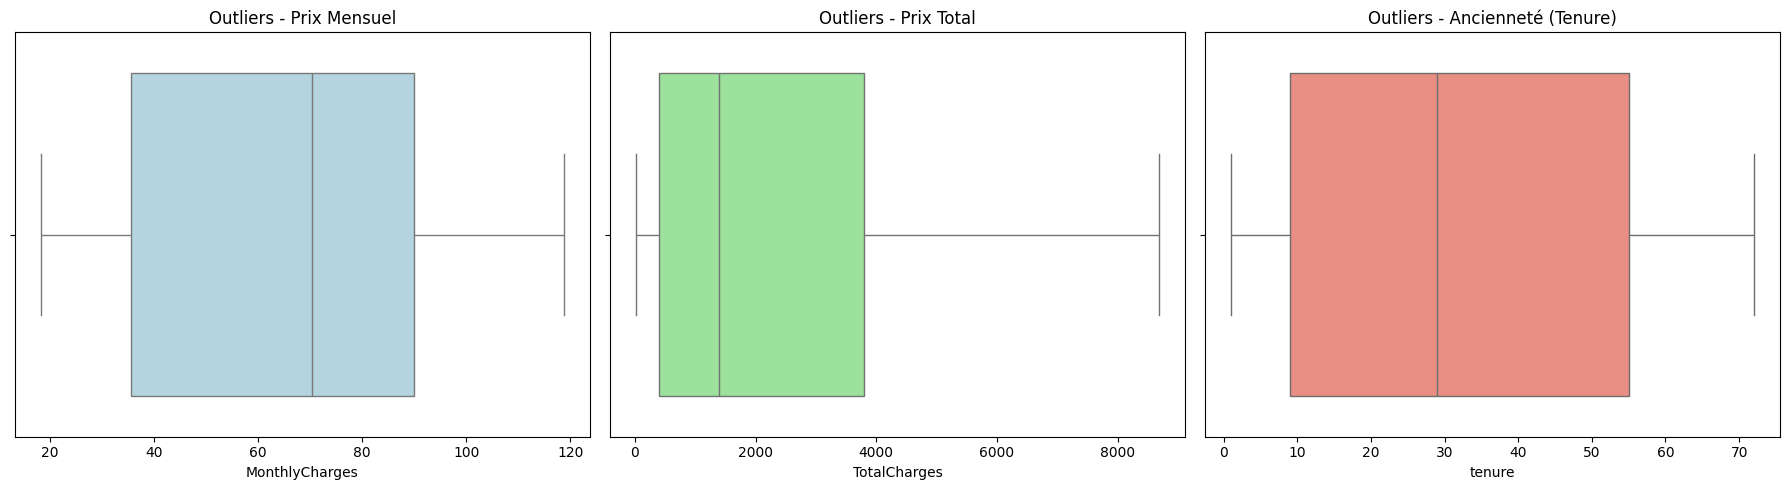

In [6]:
# On augmente un peu la largeur (18 au lieu de 12) pour que les 3 soient bien lisibles
plt.figure(figsize=(18, 5))

# 1. Boxplot pour les charges mensuelles (Grille 1x3, Position 1)
plt.subplot(1, 3, 1)
sns.boxplot(x=df['MonthlyCharges'], color='lightblue')
plt.title('Outliers - Prix Mensuel')

# 2. Boxplot pour le total payé (Grille 1x3, Position 2)
plt.subplot(1, 3, 2)
sns.boxplot(x=df['TotalCharges'], color='lightgreen')
plt.title('Outliers - Prix Total')

# 3. Boxplot pour l'ancienneté (Grille 1x3, Position 3)
plt.subplot(1, 3, 3)
sns.boxplot(x=df['tenure'], color='salmon')
plt.title('Outliers - Ancienneté (Tenure)')

plt.tight_layout()
plt.show()

Interprétation :    

Nous pouvons voir à parir de nos graphiques d'outliers que nos données pour le prix mensuel, le prix toltal et l'ancienneté ne sont pas abbérentes (de par l'absence de points en dehors de nos limites et forme nette de notre graphique)
Notre graphique ne contient donc pas de valeurs aberrantes, selon les métriques que nous avons choisies.

Ce que ça peut signifier :    

- L'absence d'outliers signifie d'abord qu'il n'y a pas eu d'erreur informatique ou de faute de frappe au moment où les données ont été rentrées (par exemple : une personne payant un prix de 999999 pour son abonnement)

- La politique tarifaire de notre entreprise ne suit pas une évolution "étrange", les fourchettes de prix peuvent être vues comme classiques, le contraire ayant pu avoir une incidence sur le churn de certains clients.

### EDA-5 Visualisations
Nous souhaitons faire des visualisations pour essayer comprendre ce qui pousse un client au désabonnement

/tmp/ipykernel_24117/1045986789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


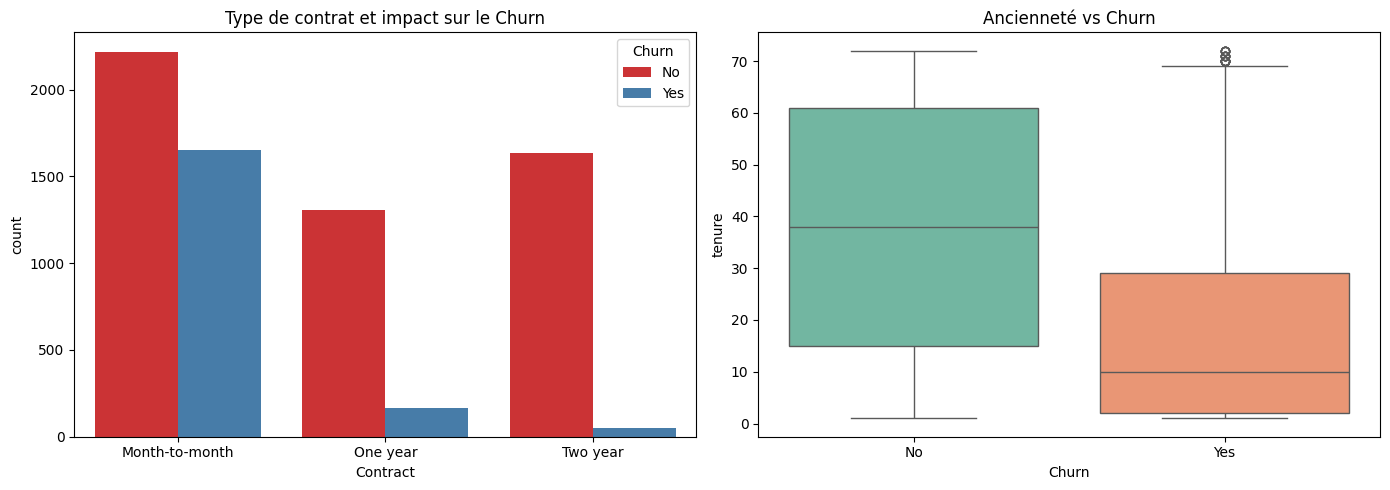

In [7]:
plt.figure(figsize=(14, 5))

# 1er Graphique : L'impact du type de contrat
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Type de contrat et impact sur le Churn')

# 2ème Graphique : Impact de l'ancienneté
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Ancienneté vs Churn')

plt.tight_layout()
plt.show()


Interprétation :    

Graphique 1 :     
- Le premier graphique montre une tendance trsè forte : la majorité des clients qui vont nous quitter sont généralement des clients ayant un type d'abonneent de type "month-to-month".
- Les clients ayant des abonnements les engageant sur une année complète ou deux années complètes sont ceux qui se désabonnent le moins de nos services.

Graphique 2 :
- Le deuxième graphique nous montre que la majorité des personnes qui ont en effet rélisilié leur abonnement (=churn) étaient dans la majorité des personnes ayant une faible ancienneté (allant de 0 à 30 mois et oscillant le plus souvent autour des 10 mois, et avec quelques valeurs n'entrant pas dans cette généralisation, comme le montre les cercles à l'extrémité de l'axe).

- Tandis que ceux maintenant leur abonnement ont souvent une ancienneté allant de 15 à 60 mois (ce qui est en moyenne plus long que lancienneté des personnes résiliant leurs abonnements).

- On peut donc en déduire que les clients ayant l'ancienneté la moins élevée sont ceuxx qui sont les plus susceptibles de nous quitter, tandis que la tendance est que plus les clients ont d'ancienneté, plus ils sont fidélisés et moins ils résilient nos services.

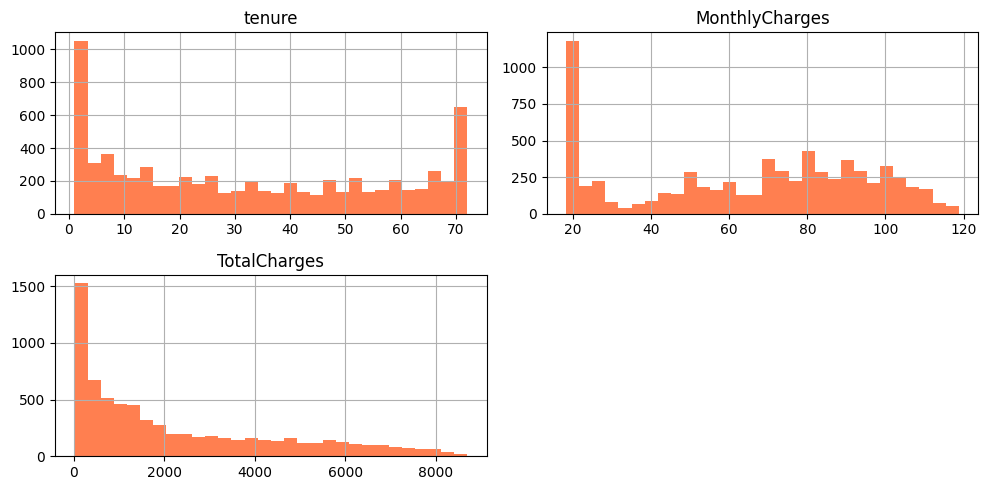

In [8]:
# Histogrammes pour analyser les distributions
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(10, 5), color='coral')
plt.tight_layout()
plt.show()

Interprétation :    

- Ancienneté (tenure) : On observe un pic des clients très récents (vers 0) ainsi qu'un pic des clients très anciens (vers 70). On peut en déduire que le défi de l'enteprise serait de maintenir les nouveaux clients assez longtemps pour qu'ils deviennent des clients de longue datemoins de chance de se désinscrire de nos services une fois fidélisés.

- Monthly Charges : On peut voir qu'une grande partie des personnes payent un abonnement d'une valeur de 20 tandis qu'un grand étalé groupe de personnes payent plus cher des prix allant de 40 à 100. Moins de personnes paynt dans les environs de 40 ou 120. Une interprétatin possible pourrait être que beaucoup de personnes ne payent qu'un seul abonneme nt (expliquant le pic d'abonnements peu cher), tandis que certaines autres personnes font des regroupements d'offres.

- TotalCharges :    La majorité des données se rrouvent sur la droite et même près de 0. Ce qui s'explique par la fait que la majorité des clients sont des clients avec peu d'ancienneté (comme vu dans de précédents graphiques) ce qui explique que la majorité des clients n'ont pas un total de dépense très élevé.

In [14]:
# Preuve numérique : Calcul exact de la skewness
skewness_total = df['TotalCharges'].skew()
print(f"La skewness de TotalCharges est de : {skewness_total:.2f}")

skewness_tenure = df['tenure'].skew()
print(f"La skewness de tenure est de : {skewness_tenure:.2f}")


La skewness de TotalCharges est de : 0.96
La skewness de tenure est de : 0.24


Interprétation :    

Pour TotalCharges la skewness est de 0.96, montrant qu'il y a une forte asymétrie des données ce que l'histogramme montrait avec uen forte asymétrie à droite. Cela pourra être corrigé par la suite lorsque l'on préparera nos données.

Pour Tenure, on pouvait voir que l'histogramme se rapprochait davantage à une forme de U, faisant penser à une possible symétrie des données, le calcul de la skewness montre qu'en effet contrairement au calcul pour total charges, le résultat semble plus bas et peut vouloir montrer une symétrie plus importante mais pas avérée étant donné que le résultat n'est pas de 0. Cependant cette forme de U confirme qu'il ne s'agit surement pas là d'une loi normale (qui se rapproche plus d'une forme de cloche.

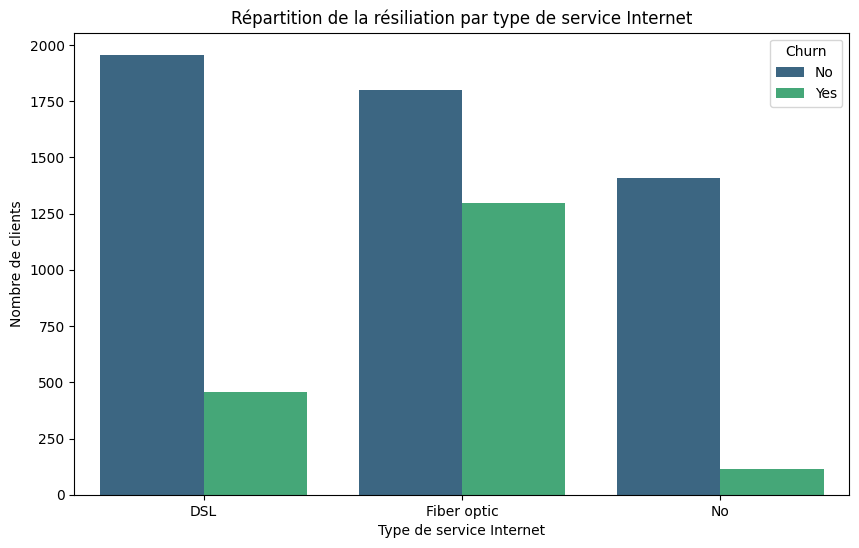

In [9]:
plt.figure(figsize=(10, 6))
# On crée un graphique à barres montrant le nombre de clients par service, coloré par Churn
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')

plt.title('Répartition de la résiliation par type de service Internet')
plt.xlabel('Type de service Internet')
plt.ylabel('Nombre de clients')
plt.show()

Interprétation :    

- On peut voir que la proportion de personnes qui résilient leur abonnement DSL est bien moins élevée que celles de personnes qui le maintiennent

- On peut également voir que pour ce qui est de la fibre optique, la proportion de personnes résiliant leurs abonnement est presque identique à celle des personnes le maintenant, ce qui peut faire se poser des questions sur la satisfaction des clients quant aux services de fibre optique, d'un point de vue global.

- No : cette colonne signifie qu'ils ne fournissent pas de services. Cela s'applique aux personnes ne prenant pas de service internet, et représentent tout le reste des clients (les clients ne prenant qu'un service téléphonique par exemple seront représenté ici), on voit que les personnes qui ne prennent pas de services internet ont bien moins tendance à se dasabonner de nos services.

Ainsi, on peut en déduire que la majorité du temps les services se faisant résilier sont des services en rapport avec internet. Cela peut nous amener à nous poser des questions quant à la satisfaction de nos services internet ou d'autres facteurs tel que leur prix, etc. Tandis que cela peut nous conforter dans l'idée que nos services hors internet satisfont globalement nos clients.

#Hypothèses

Selon les différentes obser ations que nous avons faites, nous pouvez émettre quelques hypothèses, qui seront utiles avant de passer aux étapes de modélisation :    

- Hypothèse 1 - Une vulnérabilité au niveau des nouveux clients :    
Les observations que nous avons eu tendent à montrer une certaine vulnérabilité des nouveaux clients qui semblent plus à même de résilier nos services. Nous pouvons ob server que la majorité de nos clients tendent à quitter notre enteprise dans les premiers mois et sont souvent des personnes ayant des abonnements de type month-to-month. A l'inverse, les contrats plus long (d'un an ou deux ans) ainsi que l'ancienneté du client semblent les fidéliser davantage.

- Hyphothèse 2 - Problème notre offre de ficbre optique :    
Tout comme l'un de nos graphiques précédents le montrait, parmi tous les services que nous proposons, l'un semble davantage entraîner des désabonnements que tous les autres services proposés par notre entreprise. Cela pourrait indiquer un problème de qualité de notre service ou un désavantage face à la conccurence proposant des services similaires.

- Hyphothèse 3 - Existance de deux tendances tarifaires distinctes :    
On peut voir qu'une très grande portion des abonnés ont tendance à dépenser de petites sommes, tandis qu'une autre grande partie a tedance à dépense des sommes plus élevées sans qu'il n'y ait un pic de concentration des clients pour l'un de ces différentes sommes élevées. Ce qu'il serait intéressant de jauger, serait la possible existence d'une corrélation entre lee désabonnements, en fonctio du prix payé par les abonnés.

### EDA-6 - Corrélations
Matrice des corrélations pour vérifier des liens mathématiques entre nos variables numériques.

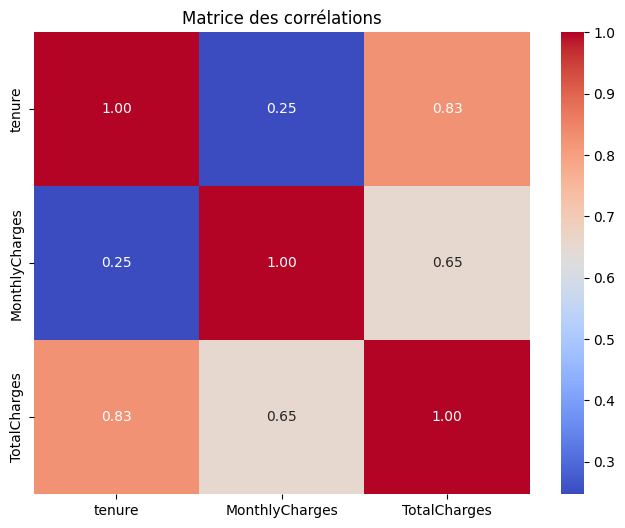

In [ ]:
plt.figure(figsize=(8, 6))

# On isole uniquement les colonnes avec des nombres pour ce calcul
donnees_numeriques = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# On génère la carte des corrélations (heatmap)
sns.heatmap(donnees_numeriques.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice des corrélations')
plt.show()

Chi2 et Cramér

In [ ]:
import scipy.stats as stats

# Fonction pour calculer le Chi2 et le V de Cramer
def analyse_cramer(colonne_etudiee, cible='Churn'):
    confusion_matrix = pd.crosstab(df[colonne_etudiee], df[cible])
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)

    # Calcul du V de Cramer
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim))

    print(f"--- {colonne_etudiee} vs {cible} ---")
    print(f"p-value (Chi²) : {p:.5f}")
    print(f"V de Cramér : {v_cramer:.5f}\n")

# On teste 3 variables catégorielles par rapport au Churn
analyse_cramer('Contract')
analyse_cramer('InternetService')
analyse_cramer('gender')

--- Contract vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.40956

--- InternetService vs Churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.32191

--- gender vs Churn ---
p-value (Chi²) : 0.49049
V de Cramér : 0.00822

